# Post-Double-Selection Lasso

Alex Ronczewski  
2026-06-22

## Outline

### Prerequisites

-   Notebook 4 of this stream: treatment, outcome, confounders, and why
    a naive comparison is biased
-   Comfort with `pandas` and basic Python at the COMET-intermediate
    level

### Learning Outcomes

By the end of this notebook you will be able to:

1.  State the convergence question and run the naive regression that
    seems to show no convergence.
2.  Say why having too many controls forces us to choose a few, and why
    choosing them by the outcome alone misses confounders.
3.  Run **post-double-selection**: pick controls that predict the
    outcome, pick controls that predict the treatment, keep both, and
    regress.
4.  State the guarantee that makes choosing controls this way safe.
5.  Read the side-by-side result and connect it back to Notebook 4.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

## 1. The Convergence Question

One of the oldest questions in growth economics is **convergence**: do
countries that start out poor grow faster and catch up to the rich ones?
We can do this by lining up countries by how rich they were in 1965 and
checking whether the poorer ones grew faster afterwards. If they did,
the relationship between 1965 wealth and later growth is negative, and
we call that convergence.

We can just run it. We load the growth data from Notebook 2, take out a
country’s wealth in 1965 and its growth rate afterwards, and regress
growth on initial wealth with nothing else in the model.

In [2]:
growth = pd.read_csv("datasets/GrowthData.csv")

D = growth["gdpsh465"].to_numpy()       # 1965 wealth (log GDP per capita): the treatment
Y = growth["Outcome"].to_numpy()        # growth rate afterwards: the outcome
controls = growth.drop(columns=["Outcome", "gdpsh465"])
C = controls.to_numpy()                 # 60 other country characteristics

print(len(Y), "countries,", C.shape[1], "other characteristics we could control for")

naive = sm.OLS(Y, sm.add_constant(D)).fit()
print(f"Growth on 1965 wealth, no controls: {naive.params[1]:+.4f}  (se {naive.bse[1]:.4f})")

90 countries, 60 other characteristics we could control for
Growth on 1965 wealth, no controls: +0.0013  (se 0.0061)

The coefficient is $+0.0013$, and its standard error is larger than the
coefficient itself. If we take this at face value, there is no
convergence: rich and poor countries grew at about the same rate. But
this regression holds nothing else fixed, so it isn’t a causal estimate,
and fixing that is what we spend the rest of the notebook on.

### 1.1 Why the naive answer cannot be trusted

The naive regression compares countries that were rich in 1965 with
countries that were poor, and then asks how fast each group grew. The
issue is that being rich in 1965 came bundled with everything else about
a country. A country that was rich in 1965 also tended to have more
schooling, better health, more developed institutions, and any of those
can drive growth on its own. So when a country that was rich in 1965
grows slowly, we cannot tell whether it is because it was rich
(convergence) or because of something else that came along with being
rich.

A variable that shapes both the treatment, 1965 wealth, and the outcome,
growth, is a **confounder**. The diagram below is the same one from
Notebook 4, relabelled for this question.

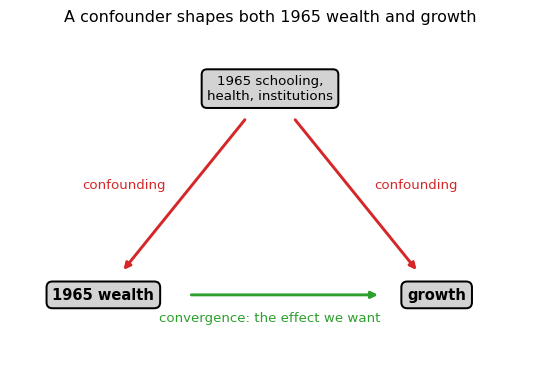

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
nodes = {"X": (0.5, 0.82), "D": (0.18, 0.2), "Y": (0.82, 0.2)}
box = dict(boxstyle="round,pad=0.4", fc="lightgrey", ec="black", lw=1.5)
ax.text(*nodes["X"], "1965 schooling,\nhealth, institutions", ha="center", va="center", fontsize=10, bbox=box)
ax.text(*nodes["D"], "1965 wealth", ha="center", va="center", fontsize=11, fontweight="bold", bbox=box)
ax.text(*nodes["Y"], "growth", ha="center", va="center", fontsize=11, fontweight="bold", bbox=box)

def arrow(start, end, color, shrinkA=30, shrinkB=24):
    ax.annotate("", xy=nodes[end], xytext=nodes[start],
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2, shrinkA=shrinkA, shrinkB=shrinkB))

arrow("X", "D", "tab:red")
arrow("X", "Y", "tab:red")
arrow("D", "Y", "tab:green", shrinkA=66, shrinkB=44)
ax.text(0.22, 0.52, "confounding", color="tab:red", ha="center", fontsize=10)
ax.text(0.78, 0.52, "confounding", color="tab:red", ha="center", fontsize=10)
ax.text(0.5, 0.12, "convergence: the effect we want", color="tab:green", ha="center", fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("A confounder shapes both 1965 wealth and growth")
plt.show()

The green arrow, from 1965 wealth to growth, is the effect we want. The
red arrows are the confounding: a country’s schooling and health in 1965
shaped both how rich it was and how fast it grew, so they pollute the
comparison we are looking for. To see the green arrow on its own we have
to hold the confounders fixed. So the naive regression for our causal
question is incomplete: it leaves the red arrows open.

### 1.2 Too many controls to keep

The data hands us 60 country characteristics from around 1965 that we
could control for. The most obvious move is to put all 60 into the
regression (after all if we wish to control everything this makes the
most sense), but notebook 2 showed why that does not work. We will run
it once more here as a reminder. We are going to run this same
regression several times with different sets of controls, so to avoid
writing it out each time we first define a small function,
`effect_of_D`: we hand it a set of controls, and it regresses growth on
1965 wealth plus those controls and returns the coefficient on 1965
wealth together with its standard error.

In [4]:
def effect_of_D(C_use):
    design = sm.add_constant(np.column_stack([D, C_use]))
    fit = sm.OLS(Y, design).fit()
    return fit.params[1], fit.bse[1]      # coefficient on 1965 wealth, and its standard error

b_all, se_all = effect_of_D(C)
print(f"All 60 controls: {b_all:+.4f}  (se {se_all:.4f})")

All 60 controls: -0.0094  (se 0.0299)

The estimate is $-0.0094$ with a standard error of $0.0299$, which is
again larger than the coefficient. With 60 controls and only 90
countries there is too little data per coefficient, so OLS overfits and
every coefficient, including the one we care about, comes out too noisy.
We have to choose only a few instead of all sixty, and in notebook 2 we
learned a tool for this: lasso.

## 2. First try: Selection on the Outcome

Lasso picks a short list of variables from our 60. We tell Lasso that
our target is growth and it keeps the controls that help predict growth
and zeroes out the rest. To do the picking it needs a **penalty**: a bar
that a control’s coefficient has to clear before lasso keeps it. In
Notebook 2 we set that bar by cross-validation, choosing whatever
predicted best, but that isn’t the right method for causal inference.
Predicting well wants to keep lots of controls, and what we want is a
short, trustworthy list, so we set the bar deliberately high.

The rule below sets the bar from three things:

-   **how noisy the target is.** A noisier target needs a higher bar
    before we believe a control is really linked to it.
-   **how many controls we are sifting through.** With 60 candidates, a
    few will look related to growth by pure luck, so the more
    candidates, the higher the bar.
-   **how many countries we have.** More data means more signal, so the
    bar can be lowered.

In [5]:
C_std = StandardScaler().fit_transform(C)   # lasso compares controls, so put them on a common scale

def select_controls(target):
    n, p = C_std.shape
    bar = 1.1 * target.std() * norm.ppf(1 - 0.05 / (2 * p)) / np.sqrt(n)
    fit = Lasso(alpha=bar, max_iter=100000).fit(C_std, target)
    return np.flatnonzero(fit.coef_)        # positions of the controls lasso kept

The exact size of the bar comes from theory (the references at the end),
but the idea is all we need: it is set high enough that a control clears
it only when its link to the target is almost certainly real and not
random. We now point it at growth and regress on whatever it keeps.

In [6]:
keep_for_growth = select_controls(Y)
b_single, se_single = effect_of_D(C[:, keep_for_growth])
print("Controls that predict growth:", len(keep_for_growth))
print(f"Estimate using them: {b_single:+.4f}  (se {se_single:.4f})")

Controls that predict growth: 0
Estimate using them: +0.0013  (se 0.0061)

Lasso keeps **no controls at all**. Growth is so hard to predict from
these characteristics that not one of them clears the bar, so this
regression is the naive one from section 1 again, and it gives back the
same $+0.0013$: no convergence.

This is the main idea of this notebook. “Does it predict growth?” is the
wrong question to ask of a control. In our control framework a control
is important by being a **confounder**, meaning it is tied to the
**treatment** (1965 wealth). A characteristic can be tightly linked to
1965 wealth and barely linked to growth, and lasso, looking only at
growth, will discard it. Those are the controls that are most important
for us to keep, and selecting on the outcome drops them.

## 3. Post-double-selection

The fix is to do the selection twice: once pointing at growth, as above,
and once pointing at 1965 wealth, the treatment. Then we keep every
control that either of our two lassos flagged, the union of the two
lists, and run the regression on that.

In [7]:
keep_for_wealth = select_controls(D)
union = sorted(set(keep_for_growth) | set(keep_for_wealth))

b_pds, se_pds = effect_of_D(C[:, union])
print("Controls that predict 1965 wealth:", len(keep_for_wealth))
print("Controls kept in total (the union):", len(union))
print("They are:", [controls.columns[i] for i in union])
print(f"Estimate using them: {b_pds:+.4f}  (se {se_pds:.4f}, t = {b_pds / se_pds:.2f})")

Controls that predict 1965 wealth: 3
Controls kept in total (the union): 3
They are: ['sf65', 'lifee065', 'humanf65']
Estimate using them: -0.0317  (se 0.0140, t = -2.26)

Pointed at 1965 wealth, lasso keeps three controls: `sf65`, `lifee065`,
and `humanf65`. Decoded with Notebook 2’s key, those are secondary
schooling among women, life expectancy, and average years of schooling
among women, all measured in 1965. They describe how educated and
healthy a country’s people were at the start. The growth lasso didn’t
keep them, because none predicts growth strongly on its own, yet each
one predicts how rich a country was in 1965, so each one confounds the
comparison. These are the controls single selection threw away, and
they’re the ones we are looking for.

With those three held fixed, the coefficient on 1965 wealth is
$-0.0317$, with a standard error of $0.0140$ and a t-statistic of
$-2.26$. It is now negative and far enough from zero to be significant.
Holding schooling and health fixed, poorer countries did grow faster.
The convergence the naive regression hid appears once we control for the
right things.

### 3.1 The conditions that make this estimate causal

Post-double-selection is a clever way to choose controls, but choosing
controls well is not what makes an estimate causal. The estimate of
$-0.0317$ carries a causal meaning only under a set of statistical
conditions, and we should be able to state them. The first two come from
Notebook 4, the third is a background condition every method in this
stream shares, and the last two are what post-double-selection adds on
top.

> **Identification conditions for post-double-selection lasso**
>
> 1.  **Unconfoundedness (selection on observables).** Every variable
>     that shapes both 1965 wealth and later growth must be among the 60
>     recorded characteristics. Formally, conditional on the controls
>     $X$, the treatment is as good as randomly assigned:
>     $(Y(0), Y(1)) \perp D \mid X$. This is an assumption about what
>     the dataset contains, not something the data can verify, and if an
>     important confounder was never measured, no way of selecting among
>     the 60 can rescue the estimate.
> 2.  **The treatment varies once the controls are held fixed.**
>     Countries with the same schooling and health must still differ in
>     their 1965 wealth. This is the overlap condition from Notebook 4,
>     in the form it takes for a continuous treatment: if the selected
>     controls pinned down 1965 wealth exactly, holding them fixed would
>     leave no variation to estimate the effect from.
> 3.  **A random, independent sample.** The theory behind the standard
>     error and the penalty rule treats the 90 countries as independent
>     and identically distributed (i.i.d.) draws. It also assumes no
>     country’s treatment spills over into another’s outcome (part of
>     what is called Stable Unit Treatment Value Assumption (SUTVA)).
> 4.  **The partially linear model is right.** We are estimating a
>     single coefficient on 1965 wealth, so we assume the effect is one
>     constant number and that the controls enter through a linear
>     combination that approximates their influence well, with an error
>     term that averages to zero given the treatment and the controls.
> 5.  **Approximate sparsity.** Among the 60 candidates, a small number
>     of controls must be enough to capture (approximately) both what
>     drives growth and what drives 1965 wealth. If the truth required
>     most of the 60, no short list could stand in for it and lasso’s
>     selection would throw away signal that matters.

When you report a post-double-selection estimate, this is the condition
checklist your causal claim rests on.

## 4. The three answers side by side

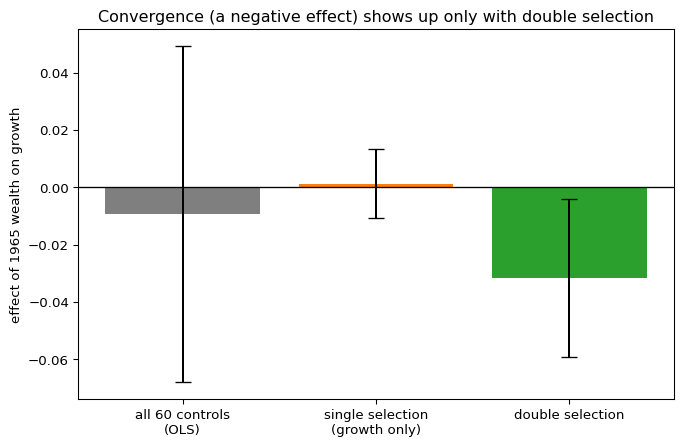

In [8]:
labels = ["all 60 controls\n(OLS)", "single selection\n(growth only)", "double selection"]
coefs = [b_all, b_single, b_pds]
bars95 = [1.96 * se_all, 1.96 * se_single, 1.96 * se_pds]

plt.figure(figsize=(8, 5))
plt.bar(labels, coefs, yerr=bars95, capsize=6,
        color=["tab:gray", "tab:orange", "tab:green"])
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("effect of 1965 wealth on growth")
plt.title("Convergence (a negative effect) shows up only with double selection")
plt.show()

The black caps on each bar are 95% confidence intervals. The
all-controls bar is wide and zero sits within the interval, so it’s too
noisy to say anything. Single selection sits just above zero, and zero
is again inside of the interval. Only double selection lands clearly
below zero. Economists have a name for the contrast: there is no
**unconditional** convergence (line all of the countries up, and rich
and poor grew alike) but there is **conditional** convergence (hold the
right starting conditions fixed and the poor grew faster). All three
regressions saw the same 90 countries and the same 60 controls. What
changed was which controls we kept, and only one way of choosing held
onto the ones that mattered.

> **Self-test**
>
> Why do we keep the **union** of the two lists rather than the controls
> that appear on **both**?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> Because a control only has to be a confounder to matter, and a
> confounder is anything tied to the treatment, whether or not it also
> predicts the outcome. Keeping the union means a control survives if
> either lasso flags it, so a confounder that the growth lasso missed is
> still kept by the wealth lasso. Keeping only the controls on both
> lists would throw away those confounders, which is the mistake we are
> trying to avoid.
>
> </details>

## 5. Connections

Notebook 4 fixed this same problem in a different way. There we removed
the controls’ influence from growth and from 1965 wealth separately,
then compared what was left over. Double selection does the same job
another way: instead of subtracting the controls’ influence, it works
out which controls belong in the model by checking both growth and 1965
wealth, then runs one regression on them. Both routes follow the same
rule we have been using from the beginning: never decide which controls
matter by looking at the outcome alone.

> **Its causal future**
>
> Lasso was just the tool we used to pick controls. Notebook 7 builds
> the generalized version, **double machine learning**, where a forest
> from Notebook 3 or any other predictor can do the picking on each
> side, and where an extra step called cross-fitting cleans up the small
> bias left from using the same countries both to choose the controls
> and to estimate the effect.

-   **Back to [Notebook
    4](notebook_04_prediction_to_treatment_effects.qmd):** double
    selection is the lasso version of removing the controls from both
    sides.
-   **Forward to [Notebook 6](notebook_06_propensity_ipw.qmd):**
    estimating the chance of treatment from the controls, the propensity
    score, and using it to reweight.

### References

-   Barro, R. J., & Lee, J.-W. (1994). *Sources of economic growth.*
    Carnegie-Rochester Conference Series on Public Policy, 40, 1-46. The
    growth data, distributed with the `hdm` package.
-   Belloni, A., Chernozhukov, V., & Hansen, C. (2014).
    *High-dimensional methods and inference on structural and treatment
    effects.* Journal of Economic Perspectives, 28(2), 29-50. The growth
    application, written for a wider audience.
-   Belloni, A., Chernozhukov, V., & Hansen, C. (2014). *Inference on
    treatment effects after selection among high-dimensional controls.*
    Review of Economic Studies, 81(2), 608-650. The
    post-double-selection method and the penalty rule.
-   Cilliers, J., Elashmawy, N., & McKenzie, D. (2024). *Using
    Post-Double Selection Lasso in Field Experiments.* World Bank
    Documents and Reports.
    https://documents1.worldbank.org/curated/en/099721209262431433/pdf/IDU-9a34656a-9be7-4ca2-ac1f-c8c30a8b071d.pdf
-   He, Y. (n.d.). *Selecting confounders.* Machine Learning Theory.
    https://machinelearningtheory.org/docs/Causal-Inference/confounder-selection/

------------------------------------------------------------------------